In [13]:
import numpy as np
path0 = './'
filename = 'all_candidate_paraphrase_pairs.txt'
threshold = 0.65  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 9:
            (sentence1, sentence2, original, paraphrase, 
             tags1, tags2, len1, len2, word_overlap) = parts
            try:
                if float(word_overlap) < threshold and int(len1) > 5 and int(len2) > 5:
                    data.append((sentence1, sentence2, original, len1, len2))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(len(data))
print(data[-1])

2018
('The panel was convinced and approved', 'They persuaded the committee to vote yes', 'They persuaded the committee to vote yes', '7', '6')


In [14]:
# # 3. Open five files and write out
# with open(f"{path0}sentences0.txt", "w") as f1, \
#      open(f"{path0}sentences1.txt", "w") as f2:
#     for s1,s2,_,_,_ in data:
#         f1.write(s1 + "\n")
#         f2.write(s2 + "\n")

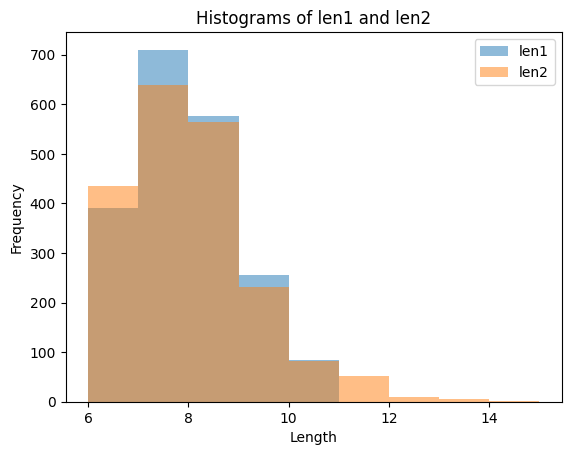

In [15]:
import matplotlib.pyplot as plt

# Extract len1 and len2 as integers
len1_list = [int(item[3]) for item in data]
len2_list = [int(item[4]) for item in data]

plt.hist(len1_list, bins=range(min(len1_list), max(len1_list)+2), alpha=0.5, label='len1')
plt.hist(len2_list, bins=range(min(len2_list), max(len2_list)+2), alpha=0.5, label='len2')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histograms of len1 and len2')
plt.show()

### Removing syntax experiment

In [16]:
def find_originals_with_indices_and_group_ids_and_data_indices_and_labels(data, 
                                                                          file1_path, 
                                                                          file2_path, 
                                                                          group_ids_path, 
                                                                          label_file_path
                                                                          ):
  # Read all lines from the first file into a list and dict for fast lookup
  with open(file1_path, "r") as f1:
    lines1 = [line.strip() for line in f1]
    line_to_idx1 = {line: idx for idx, line in enumerate(lines1)}
  # Read all lines from the second file into a list and dict for fast lookup
  with open(file2_path, "r") as f2:
    lines2 = [line.strip() for line in f2]
    line_to_idx2 = {line: idx for idx, line in enumerate(lines2)}
  # Read group ids
  with open(group_ids_path, "r") as fgid:
    group_ids = [line.strip() for line in fgid]
  results = []
  labels = []
  for data_idx, (_, _, original, _, _) in enumerate(data):
    if original in line_to_idx1:
      idx = line_to_idx1[original]
      group_id = group_ids[idx] if idx < len(group_ids) else None
      results.append((original, idx, int(group_id), data_idx))
      labels.append(0)
    elif original in line_to_idx2:
      idx = line_to_idx2[original]
      group_id = group_ids[idx] if idx < len(group_ids) else None
      results.append((original, idx, int(group_id), data_idx))
      labels.append(1)
    # else:
    #   print(f"Original sentence '{original}' not found in either file.")
  # Write labels to file
  with open(label_file_path, "w") as f:
    for label in labels:
      f.write(str(label) + "\n")
  return results,labels

file1 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences0.txt"
file2 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences1.txt"
group_ids_path = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/group_ids.txt"

""" Given the dataset of paraphrases, I use the label of who’s the 
"original" sentence (as opposed to its corresponding paraphrase). 
For that one, I have its "syntax group id", and then I can subtract to it
its corresponding "average syntax group center" vector, 
that I computed in the previous experiment. Note that this modification is only performed
 in one of the feature spaces (let’s say the "A" subspace of original sentences).
"""
results,labels = find_originals_with_indices_and_group_ids_and_data_indices_and_labels(
  data, file1, file2, group_ids_path, "original_labels.txt"
)

print(f"Number of 'original' sentences found in files: {len(results)} \n")
for i in range(5):
  print("Example:", results[i],', label=',labels[i])

Number of 'original' sentences found in files: 1613 

Example: ('The child fell on the ground and cried', 1189, 31, 0) , label= 0
Example: ('The music composed by a master sounds timeless', 1395, 37, 1) , label= 0
Example: ('We can provide an answer for your difficult question', 305, 65, 2) , label= 0
Example: ('The fuzzy caterpillar crawled on me', 234, 9, 3) , label= 0
Example: ('Failing on a test is a learning experience', 1414, 94, 4) , label= 0


In [39]:
with open("/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences0.txt", "r") as f:
  sentences0 = [line.strip() for line in f]

with open("/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences1.txt", "r") as f:
  sentences1 = [line.strip() for line in f]

with open("/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/group_ids.txt", "r") as f:
  syn_group_ids = [line.strip() for line in f]

k0 = 197
k1 = 2000
print(sentences0[k0] + ', group_id=' + syn_group_ids[k0])
print(sentences1[k1] + ', group_id=' + syn_group_ids[k1])

She would outwardly show no real emotion, group_id=58
The judge gave a harsher sentence, group_id=22


In [41]:
# Extract group_ids from originals_with_indices_and_group_ids_and_data_indices_and_labels
group_ids = [gid for _, _, gid, _ in results]

# Exported length 
batch_size = 100
L = len(group_ids) - len(group_ids) % batch_size

# Write group_ids to group_ids.txt in the current local folder
with open("group_ids.txt", "w") as f:
  for index,gid in enumerate(group_ids):
    if index < L:
      f.write(str(gid) + "\n")

In [42]:
selected_indices = list(data_idx for _, _, _, data_idx in results)

In [ ]:
# Get the set of data indices to export (truncate to L)
selected_indices = list(data_idx for _, _, _, data_idx in results)[:L]

with open("sentences0.txt", "w") as f1, open("sentences1.txt", "w") as f2:
  for idx in selected_indices:
    s1, s2, *_ = data[idx]
    f1.write(s1 + "\n")
    f2.write(s2 + "\n")

[1 2 3 4 5 6 8]


### DBG

In [ ]:
import jax.numpy as jnp
A = jnp.array([1,2,3,4,5,6,7,8,9,10])
B = jnp.array([2,3,4,5,3])
C = jnp.array([0,-1])
A[B[C]]


2025-09-01 13:27:02.172825: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


RuntimeError: Unable to initialize backend 'cuda': FAILED_PRECONDITION: No visible GPU devices. (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)